# Hierarchiczna analiza skupień metodą Warda

Notebook implementuje aglomeracyjną analizę skupień dla danych ciągłych z:
- metryką: odległość euklidesowa,
- łączeniem klastrów: metodą Warda,
- parametrem `n_clusters` sterującym liczbą grup,
- dendrogramem z podziałem na grupy i wektorem etykiet punktów.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

## Implementacja

Dla macierzy danych $X \in \mathbb{R}^{n \times p}$ algorytm startuje od $n$ jednoelementowych grup
i iteracyjnie łączy te, które najmniej zwiększają wariancję wewnątrzgrupową (kryterium Warda).

Do wyznaczenia etykiet używamy `fcluster(..., criterion='maxclust')`, a na wykresie
rysujemy poziomą linię cięcia odpowiadającą zadanej liczbie grup.

In [ ]:
def _cut_threshold_for_k_clusters(Z: np.ndarray, n_samples: int, n_clusters: int) -> float:
    """Wyznacza wysokość cięcia dendrogramu dla zadanej liczby klastrów."""
    if n_clusters <= 1:
        return float(Z[-1, 2] + 1e-9)
    if n_clusters >= n_samples:
        return float(max(0.0, Z[0, 2] - 1e-9))

    lower = Z[n_samples - n_clusters - 1, 2]
    upper = Z[n_samples - n_clusters, 2]
    return float((lower + upper) / 2.0)


def ward_hierarchical_clustering(X: np.ndarray, n_clusters: int, show_dendrogram: bool = True):
    """
    Hierarchiczna analiza skupień metodą Warda.

    Parametry
    ---------
    X : np.ndarray
        Macierz danych o kształcie (n_prób, n_cech), dane ciągłe.
    n_clusters : int
        Docelowa liczba grup.
    show_dendrogram : bool
        Czy rysować dendrogram z podziałem na grupy.

    Zwraca
    ------
    labels : np.ndarray
        Wektor etykiet klastrów (1..n_clusters) dla każdego punktu.
    Z : np.ndarray
        Macierz łączeń (linkage matrix) zgodna ze scipy.
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError('X musi być macierzą 2D: (n_prób, n_cech).')

    n_samples = X.shape[0]
    if n_samples < 2:
        raise ValueError('Potrzeba co najmniej 2 punktów do klasteryzacji.')

    if not (1 <= n_clusters <= n_samples):
        raise ValueError('n_clusters musi być z przedziału [1, n_prób].')

    # Metoda Warda implikuje metrykę euklidesową.
    Z = linkage(X, method='ward', metric='euclidean')

    # Etykiety grup: 1..n_clusters
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')

    if show_dendrogram:
        threshold = _cut_threshold_for_k_clusters(Z, n_samples, n_clusters)

        plt.figure(figsize=(12, 5))
        dendrogram(
            Z,
            color_threshold=threshold,
            above_threshold_color='gray',
            no_labels=False
        )
        plt.axhline(y=threshold, color='black', linestyle='--', linewidth=1.2,
                    label=f'Poziom cięcia dla k={n_clusters}')
        plt.title(f'Dendrogram (Ward, metryka euklidesowa), liczba grup = {n_clusters}')
        plt.xlabel('Indeks punktu')
        plt.ylabel('Odległość / przyrost SSE')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return labels, Z

## Przykład użycia na danych syntetycznych

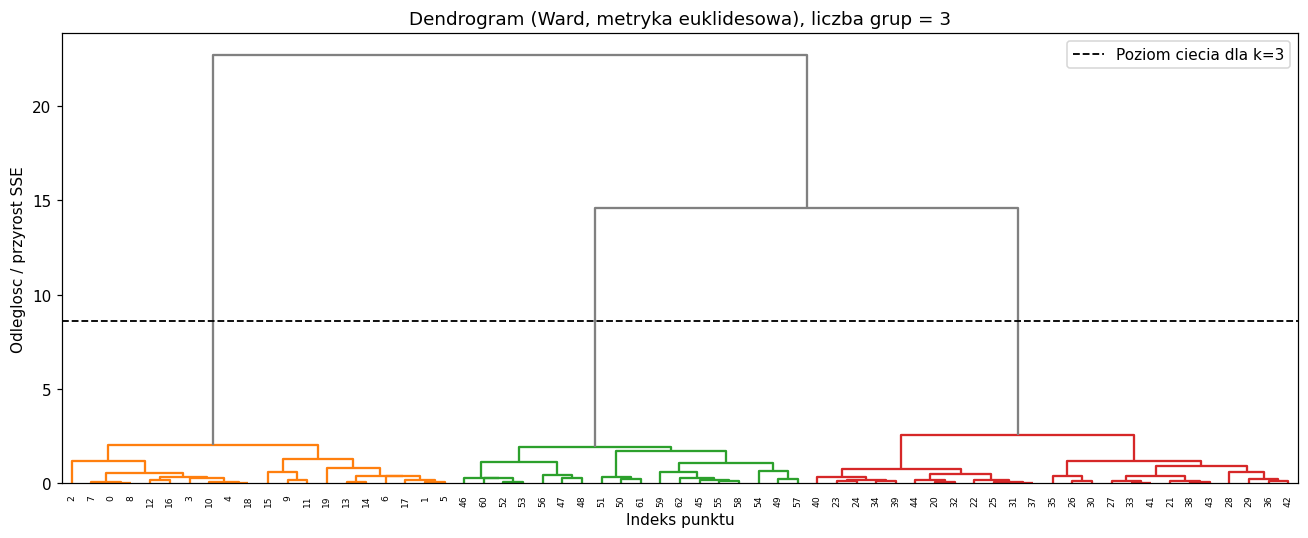

Liczba punktow: 63
Wektor etykiet (pierwsze 25): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3]
Unikalne etykiety: [1 2 3]


In [ ]:
rng = np.random.default_rng(42)

# Trzy skupiska 2D
cluster_a = rng.normal(loc=[-2.5, -1.0], scale=[0.45, 0.40], size=(20, 2))
cluster_b = rng.normal(loc=[2.0, 0.0], scale=[0.55, 0.35], size=(25, 2))
cluster_c = rng.normal(loc=[0.5, 3.0], scale=[0.40, 0.50], size=(18, 2))
X_demo = np.vstack([cluster_a, cluster_b, cluster_c])

n_clusters = 3
labels, Z = ward_hierarchical_clustering(X_demo, n_clusters=n_clusters, show_dendrogram=True)

print(f'Liczba punktów: {X_demo.shape[0]}')
print(f'Wektor etykiet (pierwsze 25): {labels[:25]}')
print(f'Unikalne etykiety: {np.unique(labels)}')

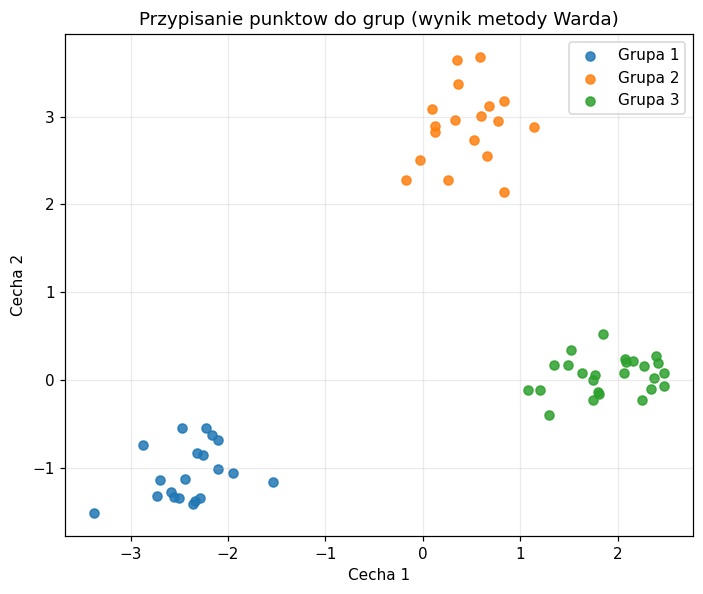

In [ ]:
# Podgląd klastrów w 2D (dla danych demo)
plt.figure(figsize=(6.5, 5.5))
for group_id in np.unique(labels):
    mask = labels == group_id
    plt.scatter(X_demo[mask, 0], X_demo[mask, 1], s=35, alpha=0.85, label=f'Grupa {group_id}')

plt.title('Przypisanie punktów do grup (wynik metody Warda)')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Użycie na własnych danych

Podstaw swoją macierz `X` o kształcie `(n_prób, n_cech)` i ustaw liczbę grup.

In [ ]:
# Przykład szablonu:
# X = ...  # np.ndarray z danymi ciągłymi
# labels, Z = ward_hierarchical_clustering(X, n_clusters=4, show_dendrogram=True)
# print(labels)